# <center>Fake News Detection from English News Articles</center>

## Introduction - A Binary Classification Problem
##### **Definition:** Fake news detection is the computational task of automatically identifying whether a piece of text — such as a news article — is factually accurate (REAL) or deliberately misleading (FAKE), using natural language processing and machine learning techniques [Shu et al., Fake News Detection on Social Media, IEEE Data Engineering Bulletin, 2017].
##### **Applications:** Applications include flagging misinformation on social media platforms, assisting journalists in automated fact-checking, improving the reliability of search engine results, combating political disinformation campaigns, and supporting automated content moderation systems at scale.

## Input & Output

##### **Input:** An English news article (title and body text combined)
##### **Output:** Predicted label — **REAL** or **FAKE**

## Examples (ISOT Fake and Real News Dataset)

| **Sr. No** | **News Article Input (Title + Text)**                                                      | **Label (Output)** |
| ---------- | ------------------------------------------------------------------------------------------ | ------------------ |
| 1          | As U.S. budget fight looms, Republicans flip their fiscal script — WASHINGTON (Reuters)... | REAL               |
| 2          | BREAKING: Deep state exposed — government sources confirm massive cover-up is underway...  | FAKE               |
| 3          | Trump to order withdrawal from Trans-Pacific Partnership — President-elect Donald Trump... | REAL               |

## Developer and System Information

| **Field**                | **Details**                                                                          |
|--------------------------|--------------------------------------------------------------------------------------|
| **Program Name**         | fake_news_detection                                                                  |
| **IDE**                  | Google Colab (Jupyter Notebook)                                                      |
| **Programming Language** | Python 3.x                                                                           |
| **Libraries**            | pandas, numpy, matplotlib, seaborn, scikit-learn, joblib, nltk                      |
| **Dataset**              | ISOT Fake and Real News Dataset — True.csv & Fake.csv (Kaggle)                      |
| **Dataset Link**         | https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset           |
| **Input Feature**        | News_Content = title + text (combined)                                               |
| **ML Algorithm**         | Logistic Regression with TF-IDF features                                             |

## Table of Contents

- *Step 1:* Import Libraries

- *Step 2:* Load Full Dataset (True.csv and Fake.csv) from Google Drive
  - Step 2.1: Mount Google Drive
  - Step 2.2: Load True.csv and Fake.csv
  - Step 2.3: Add Label Column to Each Dataset
  - Step 2.4: Combine Title and Text into a Single Input Column (News_Content)
  - Step 2.5: View Columns in Dataset
  - Step 2.6: Create Balanced Sample Data (50 REAL + 50 FAKE = 100 instances)
  - Step 2.7: Count Number of Unique Labels
  - Step 2.8: Visualise Label Distribution
  - Step 2.9: Save Sample Data as sample_news.csv

- *Step 3:* Data Cleaning and Preprocessing
  - Step 3.1: Download and Set Stopwords
  - Step 3.2: Write Function to Clean Text
  - Step 3.3: Load Sample Data (sample_news.csv)
  - Step 3.4: Drop Rows with NaN Values in Text Column
  - Step 3.5: Apply Function to Clean Text
  - Step 3.6: Data After Cleaning and Preprocessing
  - Step 3.7: Save Cleaned Data as Separate CSV File (cleaned_sample_news.csv)

- *Step 4:* Split Sample Data (cleaned_sample_news.csv) into Training and Testing Sets

- *Step 5:* Feature Extraction from Text (using TF-IDF Vectorizer)
  - Step 5.1: Train tfidf_vectorizer using Training Data
  - Step 5.2: Transform Training Text into Feature Vectors using tfidf_vectorizer (trained in Step 5.1)
  - Step 5.3: Transform Testing Text into Feature Vectors using tfidf_vectorizer (trained in Step 5.1)
  - Step 5.4: Save tfidf_vectorizer

- *Step 6:* Execute the Training Phase
  - Step 6.1: Select Machine Learning Algorithm
  - Step 6.2: Train the Model (using Training Feature Vectors created in Step 5.2)
  - Step 6.3: Save the Trained Model

- *Step 7:* Execute the Testing Phase
  - Step 7.1: Load the Trained Model (saved in Step 6.3)
  - Step 7.2: Evaluate Trained Model (using Testing Feature Vectors created in Step 5.3)
  - Step 7.3: Display Evaluation Metrics and Confusion Matrix

- *Step 8:* Execute the Application Phase
  - Step 8.1: Load tfidf_vectorizer (saved in Step 5.4)
  - Step 8.2: Load Trained Model (saved in Step 6.3)
  - Step 8.3: Take Input from User
  - Step 8.4: Clean and Preprocess User Input (exactly as you did for Sample Data in Step 3)
  - Step 8.5: Apply tfidf_vectorizer to Cleaned and Preprocessed User Input
  - Step 8.6: Model Prediction

- *Step 9:* Execute the Feedback Phase
  - Step 9.1: Collect Feedback from Users and Domain Experts on Performance of the Model Deployed in the Real World
  - Step 9.2: Make a List of Potential Improvements
  - Step 9.3: Improve the Model Based on Feedback

## Data - Download Link
##### https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

### Step 1: Import Libraries

In [1]:
!pip install numpy==2.2.6 scikit-learn==1.8.0 joblib==1.5.3 -q

In [2]:
# Regular expressions library for text cleaning (e.g., removing special characters, numbers)
import re

# Pandas for loading and manipulating datasets (DataFrame structure)
import pandas as pd

# Stopwords list (common words like "the", "is") from NLTK for text preprocessing
from nltk.corpus import stopwords

# TF-IDF Vectorizer converts text into numerical feature vectors based on term frequency
from sklearn.feature_extraction.text import TfidfVectorizer

# Splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Logistic Regression — a linear classifier that works extremely well on text data
# and consistently outperforms Naive Bayes on news article classification tasks
from sklearn.linear_model import LogisticRegression

# Functions to evaluate model performance (accuracy, classification report, confusion matrix)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Natural Language Toolkit — used here mainly to download resources (like stopwords)
import nltk

# Joblib for saving and loading trained models or transformers efficiently
import joblib

# Seaborn for visually appealing statistical plots (like heatmaps of confusion matrix)
import seaborn as sns

# Matplotlib for creating and customizing visualizations
import matplotlib.pyplot as plt

# Additional metrics to evaluate the model's precision, recall, and F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

### Step 2: Load Full Dataset (True.csv and Fake.csv) from Google Drive

#### Step 2.1: Mount Google Drive

In [3]:
# Mount Google Drive so we can access the dataset files stored there.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Step 2.2: Load True.csv and Fake.csv

In [4]:
# ── Adjust these two paths to match exactly where you saved your CSV files in Drive ──
TRUE_PATH = "/content/drive/MyDrive/archive/True.csv"
FAKE_PATH = "/content/drive/MyDrive/archive/Fake.csv"

# Load the full real news dataset into a DataFrame
true_data = pd.read_csv(TRUE_PATH)

# Load the full fake news dataset into a DataFrame
fake_data = pd.read_csv(FAKE_PATH)

# Print the number of articles in each file so we can see the full dataset size
print(f"Total REAL news articles in True.csv : {len(true_data)}")
print(f"Total FAKE news articles in Fake.csv : {len(fake_data)}")

# Display first 3 rows of true_data as a quick preview
print("\nFirst 3 rows of True.csv:")
true_data.head(3)

Total REAL news articles in True.csv : 21417
Total FAKE news articles in Fake.csv : 23481

First 3 rows of True.csv:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


#### Step 2.3: Add Label Column to Each Dataset

In [5]:
# Add a 'Label' column to identify the class of each article.
# REAL → articles from True.csv  (sourced from Reuters — verified journalism)
# FAKE → articles from Fake.csv  (sourced from known fake news websites)
true_data['Label'] = 'REAL'
fake_data['Label'] = 'FAKE'

print("Label column added to both datasets.")
print(f"Columns in true_data : {list(true_data.columns)}")
print(f"Columns in fake_data : {list(fake_data.columns)}")

Label column added to both datasets.
Columns in true_data : ['title', 'text', 'subject', 'date', 'Label']
Columns in fake_data : ['title', 'text', 'subject', 'date', 'Label']


#### Step 2.4: Combine Title and Text into a Single Input Column (News_Content)

In [6]:
# The dataset provides two text fields per article:
#   'title' → the short news headline
#   'text'  → the full body of the article
#
# We combine BOTH into one field called 'News_Content' separated by a space.
# Using title + text together gives the model more signal than either alone:
#   - The title captures headline-level language patterns (sensationalism is a strong FAKE marker)
#   - The article text captures writing style, sourcing cues, and factual consistency
# Together they give the richest possible input for the classifier.
true_data['News_Content'] = true_data['title'].astype(str) + ' ' + true_data['text'].astype(str)
fake_data['News_Content'] = fake_data['title'].astype(str) + ' ' + fake_data['text'].astype(str)

print("News_Content column created (title + text combined).")
print(f"\nExample from True.csv (first 300 chars):")
print(true_data['News_Content'].iloc[0][:300])

News_Content column created (title + text combined).

Example from True.csv (first 300 chars):
As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged b


#### Step 2.5: View Columns in Dataset

In [7]:
# Display all column names of the dataset
# This helps to understand what features are available
print("Columns in true_data :", list(true_data.columns))
print("Columns in fake_data :", list(fake_data.columns))

Columns in true_data : ['title', 'text', 'subject', 'date', 'Label', 'News_Content']
Columns in fake_data : ['title', 'text', 'subject', 'date', 'Label', 'News_Content']


#### Step 2.6: Create Balanced Sample Data (50 REAL + 50 FAKE = 100 instances)

In [8]:
# Create a balanced sample dataset with 100 instances (50 REAL and 50 FAKE).
# This mirrors the reference Sentiment notebook exactly:
#   - We keep only the columns we need: 'News_Content' and 'Label'
#   - We combine both datasets and group by 'Label'
#   - We take 50 samples from each group using random_state=42 for reproducibility
#   - If a group has fewer than 50 instances, we take all available instances

true_keep = true_data[['News_Content', 'Label']]
fake_keep = fake_data[['News_Content', 'Label']]

# Combine both into one DataFrame
combined_data = pd.concat([true_keep, fake_keep], ignore_index=True)

# Group by 'Label' and take 50 samples from each group
sample_data = combined_data.groupby('Label').apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
)

# Reset the index of the resulting DataFrame, dropping the old index
sample_data = sample_data.reset_index(drop=True)

# Add an Index column to mirror the reference dataset format (Index, News_Content, Label)
sample_data.insert(0, 'Index', sample_data.index)

# Print the total number of samples in the balanced dataset
print(f'Balanced sample data count = {len(sample_data)}\n')

# Display the first 100 rows of the balanced sample dataset for a quick preview
display(sample_data.head(100))

Balanced sample data count = 100



/tmp/ipykernel_50778/2808741642.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_data = combined_data.groupby('Label').apply(


,Index,News_Content,Label
0,0,ABOUT HILLARY’S COUGH: We Discovered The Secre...,FAKE
1,1,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,FAKE
2,2,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...,FAKE
3,3,WATCH: Kellyanne Conway Very Upset Hillary Cl...,FAKE
4,4,"GOP Gives Trump The Middle Finger, Prepares T...",FAKE
...,...,...,...
95,95,Campaign chief to oversee Trump U.S. vice pres...,REAL
96,96,U.S. lawmakers propose making it easier to mee...,REAL
97,97,Most Americans want Obama to nominate Scalia's...,REAL
98,98,Oklahoma Supreme Court strikes down restrictiv...,REAL


#### Step 2.7: Count Number of Unique Labels

In [9]:
# Count the number of unique labels in the dataset
num_labels = sample_data['Label'].nunique()
print(f"Number of unique labels: {num_labels}")

# Count the number of instances for each label
label_counts = sample_data['Label'].value_counts()
print("\nNumber of instances for each label:")
print(label_counts)

Number of unique labels: 2

Number of instances for each label:
Label
FAKE    50
REAL    50
Name: count, dtype: int64


#### Step 2.8: Visualise Label Distribution

/tmp/ipykernel_50778/192556140.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=sample_data, palette=['#C75F71', '#A2AE9D'])


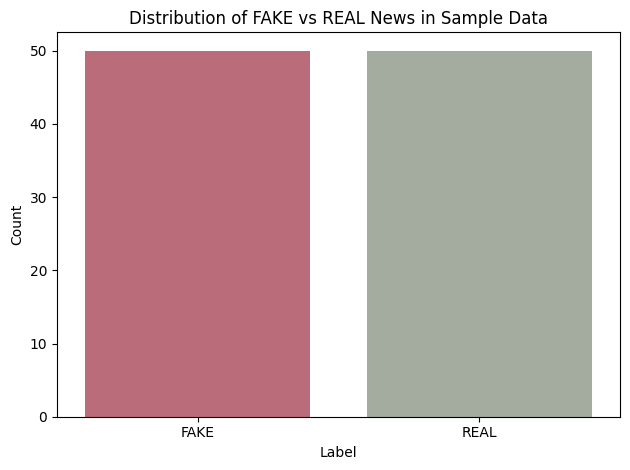

In [10]:
sns.countplot(x='Label', data=sample_data, palette=['#C75F71', '#A2AE9D'])
plt.title("Distribution of FAKE vs REAL News in Sample Data")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Step 2.9: Save Sample Data as sample_news.csv

In [11]:
# Save the balanced 100-instance sample to a CSV file called 'sample_news.csv'.
# This file will be used for all subsequent preprocessing and training steps,
# mirroring how the reference saves 'sample_comments.csv' in Step 2.
sample_data.to_csv("sample_news.csv", index=False)
print("Sample data saved as 'sample_news.csv'.")

Sample data saved as 'sample_news.csv'.


### Step 3: Data Cleaning and Preprocessing

#### Step 3.1: Download and Set Stopwords

In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# Create a set of English stopwords from NLTK.
# These are common words like "the", "is", "at", etc., which are usually removed
# because they don't add much meaning for fake news classification.
# (Make sure you've run nltk.download('stopwords') once before this step.)
stop_words = set(stopwords.words('english'))

#### Step 3.2: Write Function to Clean Text

In [14]:
# Define a function to clean a single text string (one news article at a time)
def clean_text(text):
    # 1. Remove all characters that are NOT letters or whitespace.
    #    This strips out numbers, punctuation, URLs, symbols, and special characters.
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))

    # 2. Convert the entire text to lowercase.
    #    This makes comparisons uniform (e.g., "Trump" and "trump" become the same).
    text = text.lower()

    # 3. Remove stopwords from the text.
    #    Split the text into individual words,
    #    keep only words that are NOT in the stop_words set,
    #    and join the remaining words back into a single string.
    text = ' '.join(word for word in text.split() if word not in stop_words)

    # 4. Return the cleaned text.
    return text

#### Function 1: Remove Symbols and Numbers

In [15]:
# Define a function to strip symbols and numbers from a string
def remove_symbols_numbers(text):
    # 1. Use a regular expression to keep only uppercase/lowercase letters and whitespace.
    #    Everything else (digits, punctuation, URLs, emojis, symbols) is removed.
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))

    # 2. Return the cleaned text string.
    return text

#### Function 2: Convert Text to Lowercase

In [16]:
# Define a function to convert a text string to lowercase
def to_lowercase(text):
    # 1. Convert the entire input text to lowercase.
    #    This ensures uniformity so that 'Reuters' and 'reuters' are treated the same.
    text = text.lower()

    # 2. Return the lowercase version of the text.
    return text

#### Function 3: Remove Stopwords

In [17]:
# Create a Python set of English stopwords from NLTK.
# These are very common words like "the", "is", "at", etc.,
# which usually carry little meaning for text classification tasks.
stop_words = set(stopwords.words('english'))

# Define a function to remove stopwords from a single text string
def remove_stopwords(text):
    # 1. Split the text into individual words.
    # 2. Keep only words that are NOT in the 'stop_words' set.
    # 3. Join the remaining words back into a single string separated by spaces.
    text = ' '.join(word for word in text.split() if word not in stop_words)

    # 4. Return the text without stopwords.
    return text

#### Step 3.3: Load Sample Data (sample_news.csv)

In [18]:
# Load the 100-instance sample dataset we created and saved in Step 2.9.
data = pd.read_csv("sample_news.csv")

In [19]:
# Display the entire DataFrame (all 100 rows).
# In Google Colab this will render a nicely formatted table.
data

,Index,News_Content,Label
0,0,ABOUT HILLARY’S COUGH: We Discovered The Secre...,FAKE
1,1,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,FAKE
2,2,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...,FAKE
3,3,WATCH: Kellyanne Conway Very Upset Hillary Cl...,FAKE
4,4,"GOP Gives Trump The Middle Finger, Prepares T...",FAKE
...,...,...,...
95,95,Campaign chief to oversee Trump U.S. vice pres...,REAL
96,96,U.S. lawmakers propose making it easier to mee...,REAL
97,97,Most Americans want Obama to nominate Scalia's...,REAL
98,98,Oklahoma Supreme Court strikes down restrictiv...,REAL


#### Step 3.4: Drop Rows with NaN Values in Text Column

In [20]:
# Sample data without Dropping Rows with NaN Values
print(len(data))

100


In [21]:
# Drop rows with NaN values in the text column.
# A missing News_Content value cannot be preprocessed or used for training.
data = data.dropna(subset=['News_Content'])

In [22]:
# Sample data After Dropping Rows with NaN Values
print(len(data))

100


#### Step 3.5: Apply Function to Clean Text

In [23]:
# Display only the 'News_Content' column from the DataFrame before cleaning.
# This shows the raw combined article text without any preprocessing applied.
data['News_Content']

,News_Content
0,ABOUT HILLARY’S COUGH: We Discovered The Secre...
1,BREAKING: OBAMACARE REPEAL Clears First Hurdle...
2,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...
3,WATCH: Kellyanne Conway Very Upset Hillary Cl...
4,"GOP Gives Trump The Middle Finger, Prepares T..."
...,...
95,Campaign chief to oversee Trump U.S. vice pres...
96,U.S. lawmakers propose making it easier to mee...
97,Most Americans want Obama to nominate Scalia's...
98,Oklahoma Supreme Court strikes down restrictiv...


##### Apply function to remove symbols and numbers

In [24]:
# Apply the 'remove_symbols_numbers' function to every article in the 'News_Content' column.
# This will strip out all numbers, punctuation, URLs, and symbols from each article.
# The cleaned articles are then reassigned back into the same 'News_Content' column.
#
# Using .loc[:, 'News_Content'] avoids SettingWithCopyWarning by telling pandas
# you're explicitly modifying the original DataFrame column.
data.loc[:, 'News_Content'] = data['News_Content'].apply(remove_symbols_numbers)

##### See data again to see the implementation of removal of symbols and numbers

In [25]:
# Display the contents of the 'News_Content' column after applying the cleaning function.
# In Google Colab, this will render the Series nicely.
data['News_Content']

,News_Content
0,ABOUT HILLARYS COUGH We Discovered The Secret ...
1,BREAKING OBAMACARE REPEAL Clears First HurdleD...
2,SLEEPY JUSTICE GINSBURG Excites Crowd By Sayin...
3,WATCH Kellyanne Conway Very Upset Hillary Cli...
4,GOP Gives Trump The Middle Finger Prepares To...
...,...
95,Campaign chief to oversee Trump US vice presid...
96,US lawmakers propose making it easier to meet ...
97,Most Americans want Obama to nominate Scalias ...
98,Oklahoma Supreme Court strikes down restrictiv...


##### Apply function to convert to lowercase

In [26]:
# Apply the 'to_lowercase' function to every entry in the 'News_Content' column.
# This converts all characters in each article to lowercase.
# The lowercase articles are then reassigned back into the same 'News_Content' column.
# Using .loc[:, 'News_Content'] makes sure pandas updates the original DataFrame column
# without causing a SettingWithCopyWarning.
data.loc[:, 'News_Content'] = data['News_Content'].apply(to_lowercase)

In [27]:
# Display the contents of the 'News_Content' column after the lowercase transformation.
data['News_Content']

,News_Content
0,about hillarys cough we discovered the secret ...
1,breaking obamacare repeal clears first hurdled...
2,sleepy justice ginsburg excites crowd by sayin...
3,watch kellyanne conway very upset hillary cli...
4,gop gives trump the middle finger prepares to...
...,...
95,campaign chief to oversee trump us vice presid...
96,us lawmakers propose making it easier to meet ...
97,most americans want obama to nominate scalias ...
98,oklahoma supreme court strikes down restrictiv...


##### Apply function to remove stopwords

In [28]:
# Apply the 'remove_stopwords' function to every article in the 'News_Content' column.
# This removes common English stopwords like "the", "is", "at", etc. from each article.
# The cleaned articles (without stopwords) are then reassigned back into the same column.
# Using .loc[:, 'News_Content'] avoids the SettingWithCopyWarning by telling pandas
# you're explicitly modifying the original DataFrame column.
data.loc[:, 'News_Content'] = data['News_Content'].apply(remove_stopwords)

In [29]:
# Display the contents of the 'News_Content' column after all cleaning steps
# (symbols/numbers removed → lowercased → stopwords removed).
data['News_Content']

,News_Content
0,hillarys cough discovered secret keeps coughin...
1,breaking obamacare repeal clears first hurdled...
2,sleepy justice ginsburg excites crowd saying s...
3,watch kellyanne conway upset hillary clinton t...
4,gop gives trump middle finger prepares launch ...
...,...
95,campaign chief oversee trump us vice president...
96,us lawmakers propose making easier meet auto f...
97,americans want obama nominate scalias replacem...
98,oklahoma supreme court strikes restrictive abo...


##### The clean_text function above contains all three tasks. For the sake of clarity we divided it into three separate functions above.

In [30]:
# Apply the master 'clean_text' function to re-confirm full consistency across all rows.
# This ensures every row has passed through all three cleaning steps uniformly.
data.loc[:, 'News_Content'] = data['News_Content'].apply(clean_text)

#### Step 3.6: Data After Cleaning and Preprocessing

In [31]:
# Print a header to indicate that the data shown below has been preprocessed.
print("\n\nFake News Detection Data After Preprocessing:")
print("=================================================\n")

# Configure pandas so it will display all rows and all columns of the DataFrame
# without truncating them in the console/notebook.
pd.set_option("display.max_rows", None, "display.max_columns", None)

# Show the first 5 rows of the preprocessed DataFrame to verify the top part.
print(data.head())

# Show the last 5 rows of the preprocessed DataFrame to verify the bottom part.
print(data.tail())



Fake News Detection Data After Preprocessing:

   Index                                       News_Content Label
0      0  hillarys cough discovered secret keeps coughin...  FAKE
1      1  breaking obamacare repeal clears first hurdled...  FAKE
2      2  sleepy justice ginsburg excites crowd saying s...  FAKE
3      3  watch kellyanne conway upset hillary clinton t...  FAKE
4      4  gop gives trump middle finger prepares launch ...  FAKE
    Index                                       News_Content Label
95     95  campaign chief oversee trump us vice president...  REAL
96     96  us lawmakers propose making easier meet auto f...  REAL
97     97  americans want obama nominate scalias replacem...  REAL
98     98  oklahoma supreme court strikes restrictive abo...  REAL
99     99  trump interior nominee would consider drilling...  REAL


##### We show Index first, then News_Content, then Label — mirroring the reference column order: Index → Comment → Sentiment

In [32]:
# Reorder and keep only the three columns we need:
# 'Index'        → unique identifier for each article
# 'News_Content' → the cleaned combined article text (our input feature)
# 'Label'        → the target class: REAL or FAKE
data = data[['Index', 'News_Content', 'Label']]

#### Step 3.7: Save Cleaned Data as Separate CSV File (called cleaned_sample_news.csv)

In [33]:
# Save the cleaned DataFrame to a new CSV file called 'cleaned_sample_news.csv'.
# 'index=False' tells pandas NOT to write the DataFrame's index as an extra column in the file.
data.to_csv("cleaned_sample_news.csv", index=False)
print("Cleaned data saved as 'cleaned_sample_news.csv'.")

Cleaned data saved as 'cleaned_sample_news.csv'.


In [34]:
# Display the column names of the DataFrame.
# This helps confirm that the DataFrame has the expected structure.
data.columns

Index(['Index', 'News_Content', 'Label'], dtype='object')

### Step 4: Split Sample Data (cleaned_sample_news.csv) into Training and Testing Sets

##### Splitting Data into Features and Labels

In [35]:
# Separate the features (X) and the labels (y):
# X → the cleaned combined news article text (our input feature)
# y → the label: REAL or FAKE (our prediction target)
X = data['News_Content']
y = data['Label']

# Split the data into training and testing sets.
# test_size=0.2 means 20% of the data (20 rows) goes to the test set,
# and 80% (80 rows) goes to the training set.
# random_state=42 fixes the random seed so you get the same split every time (reproducible).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print how many samples ended up in the training and test sets.
print(len(X_train))
print(len(X_test))

# Display the training features (the article texts used for training)
X_train

# Initialize the TF-IDF Vectorizer.
# max_features=500 keeps the 500 most informative words across the corpus.
# We use 500 because news articles
# are much longer and require a richer vocabulary to capture meaningful patterns.
vectorizer = TfidfVectorizer(max_features=500)

80
20


### Step 5: Feature Extraction from Text (using TF-IDF Vectorizer)

In [36]:
# Initialize a TF-IDF Vectorizer to convert text data into numerical feature vectors.
# TF-IDF stands for "Term Frequency – Inverse Document Frequency".
# It measures how important each word is in a document relative to the entire corpus.
# max_features=500 means:
#   - Build a vocabulary of only the 500 most important words across all articles.
#     longer and need a richer vocabulary to distinguish REAL from FAKE news.
# After initializing, you will 'fit' it on your training data to learn the vocabulary,
# and then 'transform' both training and test text into TF-IDF feature matrices.
vectorizer = TfidfVectorizer(max_features=500)

#### Step 5.1: Train tfidf_vectorizer using Training Data

In [37]:
# Fit the TF-IDF vectorizer on the training data ONLY.
# This step:
#   - Learns the vocabulary of the 500 most important terms from X_train
#   - Computes the IDF (inverse document frequency) for each term
# After this, the vectorizer is ready to transform text into numerical feature vectors.
# IMPORTANT: We fit ONLY on training data to prevent data leakage into the test set.
vectorizer.fit(X_train)
print("TF-IDF Vectorizer fitted on training data.")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF Vectorizer fitted on training data.
Vocabulary size: 500


#### Step 5.2: Transform Training Text into Feature Vectors using tfidf_vectorizer (trained in Step 5.1)

In [38]:
# Transform the training text data into a TF-IDF feature matrix using the fitted vectorizer.
# Each article in X_train is converted into a vector of TF-IDF values
# (based on the vocabulary learned during vectorizer.fit()).
# The result is a sparse matrix of shape (80, 500).
X_train_tfidf = vectorizer.transform(X_train)

In [39]:
# Convert the TF-IDF sparse matrix for the training data into a dense (regular) array,
# then wrap it into a pandas DataFrame for easier viewing and manipulation.
# 'columns=vectorizer.get_feature_names_out()' names the columns after the TF-IDF terms.
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),                       # convert sparse matrix to dense array
    columns=vectorizer.get_feature_names_out()     # use the learned vocabulary as column names
)

# Round all TF-IDF values to 2 decimal places for cleaner display.
X_train_tfidf_df = X_train_tfidf_df.round(2)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame (2 decimal places):")
X_train_tfidf_df.head()


TF-IDF Features DataFrame (2 decimal places):


,able,according,accused,acid,acting,action,actually,additional,administration,afd,agency,ago,allowed,almost,already,also,america,american,americans,among,ankara,another,area,around,arrested,asked,asking,attack,attacks,attorney,attorneys,august,australia,authorities,away,back,bad,ban,bank,barack,become,believed,bernie,bill,billion,black,border,boucher,bourdain,bowling,britain,brought,budget,business,california,call,called,came,campaign,candidate,candidates,care,carolina,case,cases,center,certain,chairman,change,charges,charlottesville,chief,children,china,chinese,christie,citizens,city,clinton,closed,college,come,comes,comey,comment,commission,committed,committee,company,confirmed,congress,continue,control,corruption,cost,costs,could,countries,country,couric,course,court,crimes,criminal,crisis,crowd,cruz,cummings,currently,data,david,day,days,deal,debt,decided,decision,defector,defense,deficit,democrat,democratic,democrats,denied,department,deportation,deputy,described,director,diversity,documents,donald,early,economic,economy,efforts,elected,election,emergency,end,energy,enforcement,eu,european,even,event,ever,every,everyone,example,exchange,executive,eye,face,facebook,failed,family,far,fbi,federal,filed,financial,find,first,flint,florida,following,food,force,foreign,former,found,four,friday,fuel,funding,gas,general,get,give,given,go,going,government,governor,greece,green,group,gun,harris,head,health,healthcare,help,high,hillary,hit,home,house,however,husband,ice,illegal,image,images,immediately,immigrants,immigration,important,including,influence,information,interior,international,interview,investigation,issue,issues,james,jan,job,john,joined,july,justice,keep,kids,killed,know,known,korea,last,laundering,law,lawmakers,laws,lawsuit,lawyer,lead,leader,leaders,least,lee,left,legal,legislation,less,letter,like,little,living,lockheed,long,longer,look,lottery,lozoya,made,major,make,making,man,management,many,march,matter,may,means,media,medical,meet,meeting,member,members,mexico,michael,military,million,minister,mnuchin,monday,money,month,move,mr,much,mueller,muslim,must,name,national,need,never,new,news,next,nieto,night,nominee,north,nothing,novanto,obama,obamacare,odebrecht,office,official,officials,oil,oklahoma,one,opposition,order,others,pain,palin,parliament,part,party,paul,pena,people,percent,petry,place,plan,plans,point,police,policy,political,politics,position,possible,post,president,presidential,press,previously,prime,probe,process,program,proposed,public,pump,put,putin,rally,read,real,really,reason,received,recent,recently,remain,reopen,reported,reports,representative,republican,republicans,request,respond,response,reuters,review,right,rights,robert,rockefeller,role,rules,russian,ryan,said,sanders,say,saying,says,scandal,school,schools,secretary,security,see,seen,seinfeld,senate,senator,senior,sent,serious,services,set,several,show,since,six,snyder,social,someone,something,sought,south,speaker,speaking,speech,spokesman,spokeswoman,staff,state,statement,states,status,steps,still,stop,story,students,sunday,support,supreme,syria,syrian,taiwan,take,taken,talking,team,terrorist,texas,thing,things,think,thought,three,thursday,time,today,told,took,top,trauma,travel,trump,trumps,tuesday,turkey,turkish,turn,twitter,two,understand,united,university,us,use,used,various,vcdl,via,video,violence,visa,vote,voters,want,wanted,wants,war,washington,way,wednesday,week,well,went,whether,white,wife,wilson,win,without,wolf,woman,women,words,work,working,world,would,wrote,year,yearold,years,yet,york,young,zinke
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.07,0.0,0.06,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.19,0.09,0.0,0.0,0.0,0.0,0.05,0.0,0.08,0.0,0.07,0.07,0.0,0.0,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.00,0.08,0.0,0.00,0.00,0.00,0.0,0.00,0.07,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.13,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.16,0.05,0.07,0.00,0.0

#### Step 5.3: Transform Testing Text into Feature Vectors using tfidf_vectorizer (trained in Step 5.1)

In [40]:
# Transform the test text data into a TF-IDF feature matrix using the fitted vectorizer.
# Each article in X_test is converted into a vector of TF-IDF values
# (based on the vocabulary learned during vectorizer.fit()).
# We use .transform() only — NOT .fit_transform() — to prevent data leakage.
X_test_tfidf = vectorizer.transform(X_test)

# Convert the TF-IDF sparse matrix for the test data into a dense (regular) array,
# then wrap it into a pandas DataFrame for easier viewing.
# The column names correspond to the learned vocabulary terms.
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame:")
X_test_tfidf_df.head()

# TODO: Parameter Tuning
# We are currently using max_features=500 for TfidfVectorizer.
# For this 100-instance toy dataset, max_features=500 provides a good balance.


TF-IDF Features DataFrame:


,able,according,accused,acid,acting,action,actually,additional,administration,afd,agency,ago,allowed,almost,already,also,america,american,americans,among,ankara,another,area,around,arrested,asked,asking,attack,attacks,attorney,attorneys,august,australia,authorities,away,back,bad,ban,bank,barack,become,believed,bernie,bill,billion,black,border,boucher,bourdain,bowling,britain,brought,budget,business,california,call,called,came,campaign,candidate,candidates,care,carolina,case,cases,center,certain,chairman,change,charges,charlottesville,chief,children,china,chinese,christie,citizens,city,clinton,closed,college,come,comes,comey,comment,commission,committed,committee,company,confirmed,congress,continue,control,corruption,cost,costs,could,countries,country,couric,course,court,crimes,criminal,crisis,crowd,cruz,cummings,currently,data,david,day,days,deal,debt,decided,decision,defector,defense,deficit,democrat,democratic,democrats,denied,department,deportation,deputy,described,director,diversity,documents,donald,early,economic,economy,efforts,elected,election,emergency,end,energy,enforcement,eu,european,even,event,ever,every,everyone,example,exchange,executive,eye,face,facebook,failed,family,far,fbi,federal,filed,financial,find,first,flint,florida,following,food,force,foreign,former,found,four,friday,fuel,funding,gas,general,get,give,given,go,going,government,governor,greece,green,group,gun,harris,head,health,healthcare,help,high,hillary,hit,home,house,however,husband,ice,illegal,image,images,immediately,immigrants,immigration,important,including,influence,information,interior,international,interview,investigation,issue,issues,james,jan,job,john,joined,july,justice,keep,kids,killed,know,known,korea,last,laundering,law,lawmakers,laws,lawsuit,lawyer,lead,leader,leaders,least,lee,left,legal,legislation,less,letter,like,little,living,lockheed,long,longer,look,lottery,lozoya,made,major,make,making,man,management,many,march,matter,may,means,media,medical,meet,meeting,member,members,mexico,michael,military,million,minister,mnuchin,monday,money,month,move,mr,much,mueller,muslim,must,name,national,need,never,new,news,next,nieto,night,nominee,north,nothing,novanto,obama,obamacare,odebrecht,office,official,officials,oil,oklahoma,one,opposition,order,others,pain,palin,parliament,part,party,paul,pena,people,percent,petry,place,plan,plans,point,police,policy,political,politics,position,possible,post,president,presidential,press,previously,prime,probe,process,program,proposed,public,pump,put,putin,rally,read,real,really,reason,received,recent,recently,remain,reopen,reported,reports,representative,republican,republicans,request,respond,response,reuters,review,right,rights,robert,rockefeller,role,rules,russian,ryan,said,sanders,say,saying,says,scandal,school,schools,secretary,security,see,seen,seinfeld,senate,senator,senior,sent,serious,services,set,several,show,since,six,snyder,social,someone,something,sought,south,speaker,speaking,speech,spokesman,spokeswoman,staff,state,statement,states,status,steps,still,stop,story,students,sunday,support,supreme,syria,syrian,taiwan,take,taken,talking,team,terrorist,texas,thing,things,think,thought,three,thursday,time,today,told,took,top,trauma,travel,trump,trumps,tuesday,turkey,turkish,turn,twitter,two,understand,united,university,us,use,used,various,vcdl,via,video,violence,visa,vote,voters,want,wanted,wants,war,washington,way,wednesday,week,well,went,whether,white,wife,wilson,win,without,wolf,woman,women,words,work,working,world,would,wrote,year,yearold,years,yet,york,young,zinke
0,0.11385,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.102066,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.058736,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.060737,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.048655,0.084209,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.062975,0.0,0.0,0.0,0.0,0.000000,0.0,0.0

#### Step 5.4: Save tfidf_vectorizer

In [41]:
# --- Saving the Fitted TF-IDF Vectorizer ---

# Save the fitted TF-IDF vectorizer to disk.
# 'vectorizer' contains the learned vocabulary and IDF weights.
# 'tfidf_vectorizer.pkl' is the filename where it will be stored.
# Saving the vectorizer ensures that you transform new data in the same way as training data.
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'.")

TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'.


### Step 6: Execute the Training Phase

#### Step 6.1:  Machine Learning Algorithm

##### We use **Logistic Regression** for this Fake News Detection task.
##### - Logistic Regression is a powerful linear classifier that is specifically well-suited to high-dimensional sparse feature spaces such as TF-IDF matrices.
##### - It does NOT assume that all input words are statistically independent — an assumption that real natural language clearly violates.
##### - It provides interpretable coefficient weights that reveal exactly which words are the strongest predictors of FAKE vs REAL news.

#### Step 6.2: Train the Model (using Training Feature Vectors created in Step 5.2)

In [42]:
# --- Training the Logistic Regression Model ---

# Create an instance of the Logistic Regression classifier.
# max_iter=1000 gives the solver enough iterations to fully converge.
# random_state=42 ensures training results are reproducible.
model = LogisticRegression(max_iter=1000, random_state=42)

# Fit (train) the model on the training data.
# X_train_tfidf : TF-IDF feature matrix for the 80 training news articles.
# y_train       : Actual labels (REAL / FAKE) for those 80 training articles.
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### Step 6.3: Save the Trained Model

In [43]:
# --- Saving the Trained Model ---

# Save the trained Logistic Regression model to disk.
# 'model' is your trained LogisticRegression classifier.
# 'fake_news_lr_model.pkl' is the filename where it will be stored.
joblib.dump(model, 'fake_news_lr_model.pkl')

# Save the fitted TF-IDF vectorizer to disk.
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model saved as      'fake_news_lr_model.pkl'.")
print("Vectorizer saved as 'tfidf_vectorizer.pkl'.")

Model saved as      'fake_news_lr_model.pkl'.
Vectorizer saved as 'tfidf_vectorizer.pkl'.


### Step 7: Execute the Testing Phase

#### Step 7.1: Load the Trained Model (saved in Step 6.3)

In [44]:
'''
*------------------- LOAD_SAVED_MODEL --------------------------*
|         Function: load()                                      |
|               Purpose: Method to Load Previously Saved Model  |
|         Arguments:                                            |
|               Model: Trained Model                            |
|         Return:                                               |
|               File: Saved Model will be Loaded in Memory      |
*---------------------------------------------------------------*
'''

import joblib  # Used for saving and loading Python objects such as models and vectorizers

# Load the trained Logistic Regression model back from disk.
# This allows you to use the model without retraining.
loaded_model = joblib.load('fake_news_lr_model.pkl')

# Load the fitted TF-IDF vectorizer back from disk.
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Confirm that the model has been successfully loaded.
print("Model loaded from      'fake_news_lr_model.pkl'")
print("Vectorizer loaded from 'tfidf_vectorizer.pkl'")

Model loaded from      'fake_news_lr_model.pkl'
Vectorizer loaded from 'tfidf_vectorizer.pkl'


#### Step 7.2: Evaluate Trained Model (using Testing Feature Vectors created in Step 5.3)

In [45]:
# --- Evaluating the Loaded Model ---

# Transform the test data using the loaded TF-IDF vectorizer.
# This converts the raw text into the same numerical representation used during training.
X_test_tfidf_loaded = loaded_vectorizer.transform(X_test)

# Use the loaded model to predict the label of each test article.
# This gives you an array of predicted labels: 'REAL' or 'FAKE'.
y_pred_loaded = loaded_model.predict(X_test_tfidf_loaded)

# Compute the accuracy of the loaded model on the test set.
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)

# Generate a detailed classification report (precision, recall, F1-score for each class).
report_loaded = classification_report(y_test, y_pred_loaded)

# Display the results.
print(f"Accuracy: {accuracy_loaded}")
print("Classification Report:")
print(report_loaded)

Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      0.75      0.86        12
        REAL       0.73      1.00      0.84         8

    accuracy                           0.85        20
   macro avg       0.86      0.88      0.85        20
weighted avg       0.89      0.85      0.85        20



#### Step 7.3: Display Evaluation Metrics and Confusion Matrix


Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score
0,0.85,0.890909,0.85,0.851128



Confusion Matrix Table:


,Predicted FAKE,Predicted REAL
Actual FAKE,9,3
Actual REAL,0,8


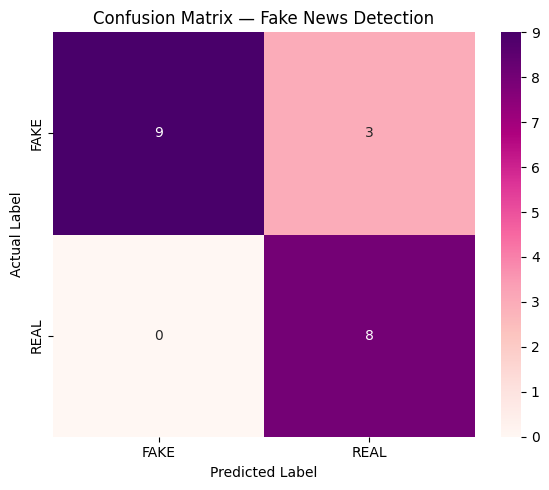

In [46]:
# --- Compute Evaluation Metrics ---

# Calculate accuracy on the test set.
accuracy  = accuracy_score(y_test, y_pred_loaded)

# Calculate weighted precision across both classes.
precision = precision_score(y_test, y_pred_loaded, average='weighted')

# Calculate weighted recall across both classes.
recall    = recall_score(y_test, y_pred_loaded, average='weighted')

# Calculate weighted F1-score across both classes.
f1        = f1_score(y_test, y_pred_loaded, average='weighted')

# Combine all metrics into a single DataFrame for easier display.
metrics_df = pd.DataFrame(
    {
        'Accuracy':  [accuracy],
        'Precision': [precision],
        'Recall':    [recall],
        'F1-Score':  [f1]
    }
)

# Display the evaluation metrics as a table.
print("\nEvaluation Metrics:")
display(metrics_df)


# --- Confusion Matrix ---

# Create the confusion matrix from actual vs predicted labels.
conf_matrix = confusion_matrix(y_test, y_pred_loaded, labels=['FAKE', 'REAL'])

# Put it into a DataFrame for readable row/column labels.
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual FAKE', 'Actual REAL'],
    columns=['Predicted FAKE', 'Predicted REAL']
)

# Display the confusion matrix as a table.
print("\nConfusion Matrix Table:")
display(conf_matrix_df)


# --- Plot the Confusion Matrix as a Heatmap ---

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d', cmap='RdPu',
    xticklabels=['FAKE', 'REAL'],
    yticklabels=['FAKE', 'REAL']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Fake News Detection')
plt.tight_layout()
plt.show()

### Step 8: Execute the Application Phase

#### Step 8.1: Load tfidf_vectorizer (saved in Step 5.4)

In [47]:
# Load the TF-IDF vectorizer from disk.
# This vectorizer contains the exact vocabulary and IDF weights used during training.
vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Confirm that the vectorizer has been successfully loaded.
print("Vectorizer loaded from 'tfidf_vectorizer.pkl'")

Vectorizer loaded from 'tfidf_vectorizer.pkl'


#### Step 8.2: Load Trained Model (saved in Step 6.3)

In [48]:
# Load the trained Logistic Regression model from disk.
# This model was trained on TF-IDF features produced by the vectorizer above.
model = joblib.load('fake_news_lr_model.pkl')

# Confirm that the model has been successfully loaded.
print("Model loaded from 'fake_news_lr_model.pkl'")

Model loaded from 'fake_news_lr_model.pkl'


#### Step 8.3: Take Input from User

In [49]:
# --- Take input text from the user ---
# Ask the user to enter a news article (title and/or body text).
# .strip() removes any leading or trailing whitespace.
user_input = input("Please enter a news article (title and/or text): ").strip()

# --- Define a function to preprocess the user input ---
def preprocess_user_input(text):
    # Load English stop words.
    stop_words = set(stopwords.words('english'))

    # Remove all non-alphabetic characters (numbers, punctuation, URLs, symbols).
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))

    # Convert to lowercase for uniformity.
    text = text.lower()

    # Remove stop words.
    text = ' '.join(word for word in text.split() if word not in stop_words)

    return text

Please enter a news article (title and/or text): Residents report seeing strange flying objects hovering over buildings at midnight. Experts say it's impossible.


In [50]:
# Display the original, unprocessed user input.
user_input

"Residents report seeing strange flying objects hovering over buildings at midnight. Experts say it's impossible."

#### Step 8.4: Clean and Preprocess User Input (exactly as you did for Sample Data in Step 3)

In [51]:
# Apply the preprocessing function to the raw user input.
cleaned_input = preprocess_user_input(user_input)

# Display the cleaned version of the input.
cleaned_input

'residents report seeing strange flying objects hovering buildings midnight experts say impossible'

#### Step 8.5: Apply tfidf_vectorizer to Cleaned and Preprocessed User Input (transform User Input into a Feature Vector — exactly as you did for Training and Testing Data)

In [52]:
# Transform the preprocessed user input using the loaded TF-IDF vectorizer.
# Because the vectorizer expects an iterable of texts, we wrap cleaned_input in a list.
X_test_tfidf = vectorizer.transform([cleaned_input])

# Convert the resulting sparse matrix into a dense DataFrame for inspection.
# Use the learned vocabulary terms from the vectorizer as the column names.
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Display the TF-IDF feature values for the user input.
print("\nTF-IDF Features DataFrame for User Input:")
print(X_test_tfidf_df)


TF-IDF Features DataFrame for User Input:
   able  according  accused  acid  acting  action  actually  additional  \
0   0.0        0.0      0.0   0.0     0.0     0.0       0.0         0.0   

   administration  afd  agency  ago  allowed  almost  already  also  america  \
0             0.0  0.0     0.0  0.0      0.0     0.0      0.0   0.0      0.0   

   american  americans  among  ankara  another  area  around  arrested  asked  \
0       0.0        0.0    0.0     0.0      0.0   0.0     0.0       0.0    0.0   

   asking  attack  attacks  attorney  attorneys  august  australia  \
0     0.0     0.0      0.0       0.0        0.0     0.0        0.0   

   authorities  away  back  bad  ban  bank  barack  become  believed  bernie  \
0          0.0   0.0   0.0  0.0  0.0   0.0     0.0     0.0       0.0     0.0   

   bill  billion  black  border  boucher  bourdain  bowling  britain  brought  \
0   0.0      0.0    0.0     0.0      0.0       0.0      0.0      0.0      0.0   

   budget  busine

#### Step 8.6: Model Prediction
##### Step 8.6.1: Apply Trained Model to the Feature Vector of the Unseen Instance (created in Step 8.5) and Return Prediction to the User

In [53]:
# Apply the trained Logistic Regression model to the user input feature vector.
user_prediction = model.predict(X_test_tfidf_df.to_numpy())

# Get prediction probabilities for both classes to display a confidence score.
user_probabilities = model.predict_proba(X_test_tfidf_df.to_numpy())
confidence = round(max(user_probabilities[0]) * 100, 1)

# Determine the label and display a clear result to the user.
predicted_label = user_prediction[0]
result = 'REAL' if predicted_label == 'REAL' else 'FAKE'

print(f"The news article is predicted to be: {result}")
print(f"Confidence: {confidence}%")

The news article is predicted to be: FAKE
Confidence: 51.4%


### Step 9: Feedback and Improvements

#### Step 9.1: Collect Feedback from Users and Experts
##### After deployment on a cloud platform (e.g., PythonAnywhere or Render), collect feedback from users and journalism/fact-checking experts.  
##### Log cases where the model made incorrect predictions and note patterns in misclassified articles.

#### Step 9.2: Make a List of Potential Improvements
##### - **More data:** Use the full dataset (~44,000 articles) to improve generalisation.  
##### - **N-grams:** Add bigrams and trigrams (`ngram_range=(1,3)`) to capture phrases like "breaking news".  
##### - **More features:** Increase `max_features` from 500 to 5000+ for richer vocabulary.  
##### - **Advanced models:** Try SVM, XGBoost, or transformer models (BERT, RoBERTa).  
##### - **Hyperparameter tuning:** Use GridSearchCV to tune parameters like `C` in Logistic Regression.

#### Step 9.3: Improve the Model Based on Feedback
##### - Add misclassified articles to the training set and retrain.  
##### - Schedule periodic retraining to adapt to new fake news patterns.  
##### - Add a feedback button in the web app ("Was this prediction correct? Yes / No") to collect real-time corrections.

## Conclusion
##### This notebook presents a complete machine learning pipeline for **fake news detection from English news articles**, where it processes written news content (title combined with body text), converts it into numerical TF-IDF feature vectors, applies a trained Logistic Regression classifier, and outputs whether the article is REAL or FAKE. The model is evaluated using accuracy, precision, recall, and F1-score, along with a visual confusion matrix heatmap. The full pipeline — from loading the raw Kaggle dataset and creating a balanced toy dataset, through preprocessing, feature extraction, training, evaluation, and live user prediction — is designed to be straightforward to deploy as a Flask web application on a cloud platform such as PythonAnywhere or Render.